# FraudScope — 01 Exploration
## EDA · Accuracy Trap · Feature Engineering · Pipeline TimeSeriesSplit

**Contexte** : PayTrack est une fintech française traitant 1,2M transactions/mois.
Son système de règles métier génère 30% de faux positifs et rate 40% des fraudes réelles.

**Objectifs de ce notebook** :
1. Explorer le dataset IEEE-CIS (590 540 transactions, 433 features, 3.5% de fraude)
2. Démontrer pourquoi l'accuracy est une métrique trompeuse sur données déséquilibrées
3. Construire des features temporelles orientées comportement frauduleux
4. Mettre en place un pipeline sklearn avec validation chronologique (`TimeSeriesSplit`)

**Règle fondamentale** : ne jamais mélanger données passées et futures dans le split d'entraînement.
Utiliser `TimeSeriesSplit`, jamais `KFold`.

## 0. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

FIGURES_DIR = Path('figures')
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TARGET = 'isFraud'
print('Imports OK')

Imports OK


## 1. Chargement des données

Les fichiers IEEE-CIS sont disponibles sur Kaggle (voir `data/get_dataset.md`).
On fusionne `train_transaction.csv` et `train_identity.csv` sur `TransactionID`.

In [2]:
DATA_DIR = Path('data')

train_tx_path  = DATA_DIR / 'train_transaction.csv'
train_id_path  = DATA_DIR / 'train_identity.csv'

assert train_tx_path.exists(), f'Fichier manquant : {train_tx_path}  →  voir data/get_dataset.md'
assert train_id_path.exists(), f'Fichier manquant : {train_id_path}  →  voir data/get_dataset.md'

print('Chargement des transactions...')
train_tx = pd.read_csv(train_tx_path)
print(f'  train_transaction : {train_tx.shape}')

print('Chargement des identités...')
train_id = pd.read_csv(train_id_path)
print(f'  train_identity    : {train_id.shape}')

df = train_tx.merge(train_id, on='TransactionID', how='left')
df = df.sort_values('TransactionDT').reset_index(drop=True)
print(f'\nDataset fusionné et trié chronologiquement : {df.shape}')
df.head(3)

# ── Réduction mémoire : downcast int64→int32/int16/int8, float64→float32 ──
def reduce_mem_usage(df, verbose=True):
    """Downcast chaque colonne numérique au type le plus petit compatible."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        col_min, col_max = df[col].min(), df[col].max()
        if str(df[col].dtype).startswith('int'):
            if   col_min >= np.iinfo(np.int8).min  and col_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            if col_min >= np.finfo(np.float32).min and col_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f'Mémoire : {start_mem:.1f} Mo → {end_mem:.1f} Mo  '
              f'({100*(start_mem-end_mem)/start_mem:.1f}% économisé)')
    return df

df = reduce_mem_usage(df)
print(f'Shape finale après downcast : {df.shape}')


Chargement des transactions...
  train_transaction : (590540, 394)
Chargement des identités...
  train_identity    : (144233, 41)

Dataset fusionné et trié chronologiquement : (590540, 434)
Mémoire : 2567.1 Mo → 1656.4 Mo  (35.5% économisé)
Shape finale après downcast : (590540, 434)


## 2. Vue d'ensemble du dataset

In [3]:
print('=== Dimensions ===')
print(f'Lignes : {df.shape[0]:,}  |  Colonnes : {df.shape[1]:,}')

print('\n=== Types ===')
print(df.dtypes.value_counts())

print('\n=== Valeurs manquantes (top 20) ===')
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(20).to_string())

print('\n=== Colonnes sans valeurs manquantes ===')
print(f'{(missing == 0).sum()} colonnes complètes sur {df.shape[1]}')

=== Dimensions ===
Lignes : 590,540  |  Colonnes : 434

=== Types ===
float32    399
object      31
int32        2
int8         1
int16        1
Name: count, dtype: int64

=== Valeurs manquantes (top 20) ===
id_24   99.1962
id_25   99.1310
id_07   99.1271
id_08   99.1271
id_21   99.1264
id_26   99.1257
id_27   99.1247
id_23   99.1247
id_22   99.1247
dist2   93.6284
D7      93.4099
id_18   92.3607
D13     89.5093
D14     89.4695
D12     89.0410
id_04   88.7689
id_03   88.7689
D6      87.6068
id_33   87.5895
id_09   87.3123

=== Colonnes sans valeurs manquantes ===
20 colonnes complètes sur 434


## 3. Analyse Exploratoire (EDA)

### 3.1 Déséquilibre de classes

               count  pct (%)
Légitime (0)  569877  96.5010
Fraude (1)     20663   3.4990

Ratio déséquilibre  : 1 fraude pour 28 transactions légitimes


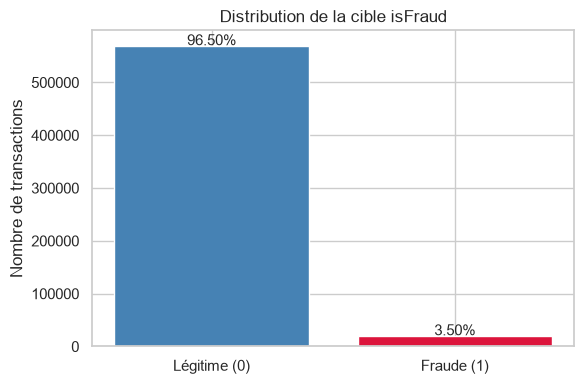

In [4]:
counts = df[TARGET].value_counts().sort_index()
pcts   = df[TARGET].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({'count': counts, 'pct (%)': pcts})
summary.index = ['Légitime (0)', 'Fraude (1)']
print(summary.to_string())

fraud_ratio = counts[1] / counts[0]
print(f'\nRatio déséquilibre  : 1 fraude pour {1/fraud_ratio:.0f} transactions légitimes')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Légitime (0)', 'Fraude (1)'], counts, color=['steelblue', 'crimson'])
ax.set_title('Distribution de la cible isFraud')
ax.set_ylabel('Nombre de transactions')
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{pcts.iloc[i]:.2f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

### 3.2 Patterns temporels

`TransactionDT` est un delta en secondes depuis une référence inconnue.
On en extrait l'heure de la journée, le jour et la semaine pour analyser les patterns.

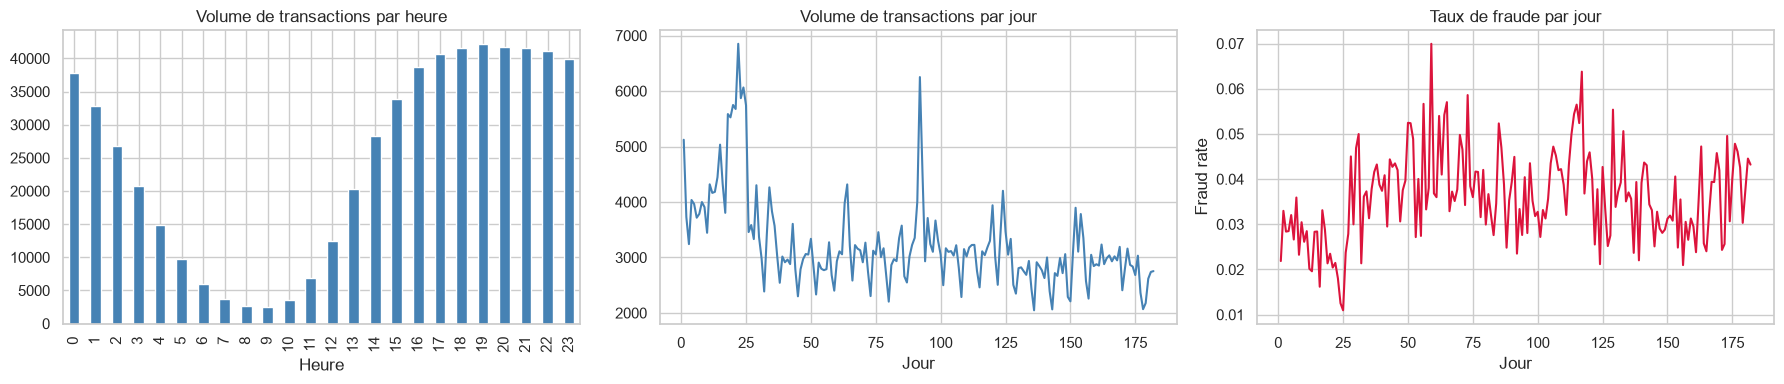

In [5]:
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  =  df['TransactionDT'] // (3600 * 24)
df['week'] =  df['TransactionDT'] // (3600 * 24 * 7)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Volume de transactions par heure')
axes[0].set_xlabel('Heure')

df.groupby('day').size().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Volume de transactions par jour')
axes[1].set_xlabel('Jour')

df.groupby('day')[TARGET].mean().plot(ax=axes[2], color='crimson')
axes[2].set_title('Taux de fraude par jour')
axes[2].set_xlabel('Jour')
axes[2].set_ylabel('Fraud rate')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_patterns.png', dpi=150)
plt.show()

### 3.3 Distribution des montants (fraude vs légitime)

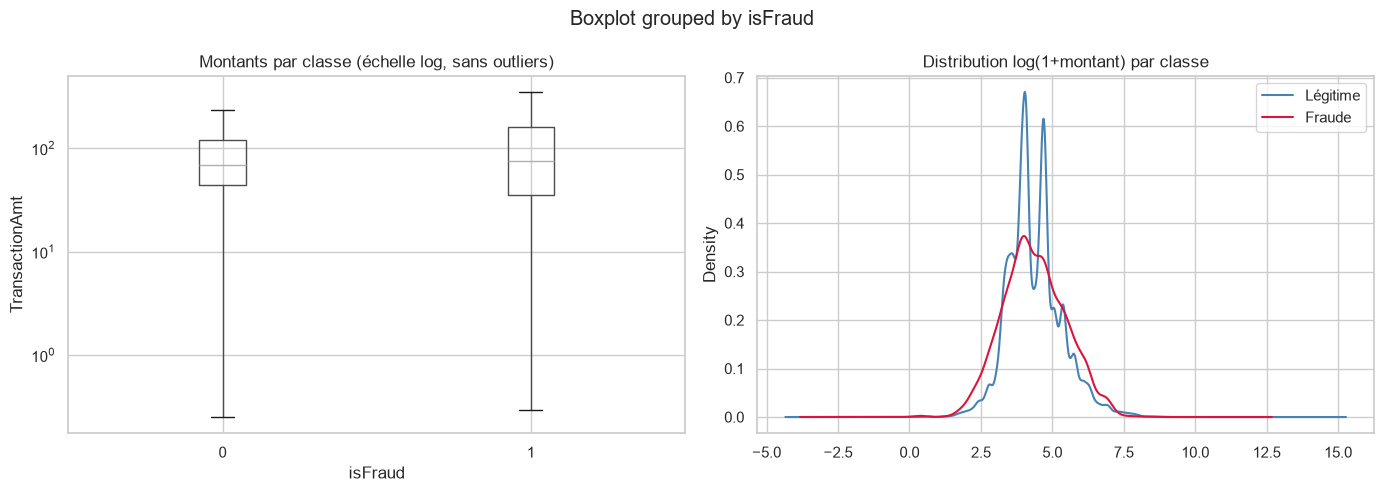

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0000,134.5117,239.3951,0.2510,43.9700,68.5000,120.0000,31937.3906
1,20663.0000,149.2448,232.2122,0.2920,35.0440,75.0000,161.0000,5191.0000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='TransactionAmt', by=TARGET, ax=axes[0], showfliers=False)
axes[0].set_yscale('log')
axes[0].set_title('Montants par classe (échelle log, sans outliers)')
axes[0].set_xlabel('isFraud')
axes[0].set_ylabel('TransactionAmt')

sample = df.sample(min(80000, len(df)), random_state=RANDOM_STATE)
for label, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = sample[sample[TARGET] == label]['TransactionAmt']
    subset_log = np.log1p(subset)
    subset_log.plot(kind='kde', ax=axes[1], color=color,
                    label='Légitime' if label == 0 else 'Fraude')
axes[1].set_title('Distribution log(1+montant) par classe')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'amount_distribution.png', dpi=150)
plt.show()

df.groupby(TARGET)['TransactionAmt'].describe()

### 3.4 Corrélations avec la cible

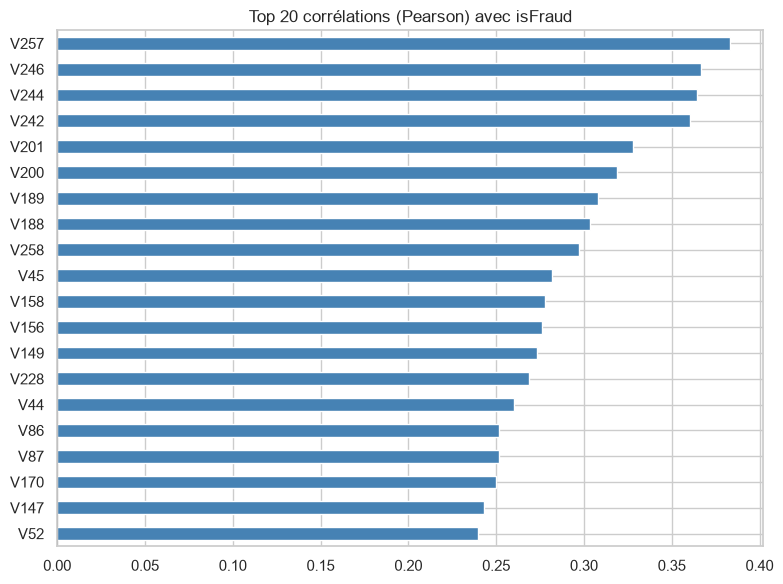

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = (
    df[numeric_cols].corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

top20 = corr_with_target.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 corrélations (Pearson) avec isFraud')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlations_target.png', dpi=150)
plt.show()

## 4. Piège de l'Accuracy

Un classificateur prédisant "toujours légitime" obtient 96.5% d'accuracy.
On démontre ici pourquoi Recall et AUPRC sont les métriques pertinentes.

In [8]:
# Split temporel simple (80/20) pour la démo du piège
split_idx = int(len(df) * 0.8)
X_tr = df.iloc[:split_idx].drop(columns=[TARGET, 'TransactionID', 'customer_proxy', 'tx_time_sec'], errors='ignore')
y_tr = df[TARGET].iloc[:split_idx]
X_va = df.iloc[split_idx:].drop(columns=[TARGET, 'TransactionID', 'customer_proxy', 'tx_time_sec'], errors='ignore')
y_va = df[TARGET].iloc[split_idx:]

# Sélectionner uniquement les colonnes numériques (pour la baseline rapide)
num_only = X_tr.select_dtypes(include=[np.number]).columns.tolist()
X_tr_num = X_tr[num_only]
X_va_num = X_va[num_only]

print(f'Train : {X_tr_num.shape}  |  Valid : {X_va_num.shape}')

Train : (472432, 404)  |  Valid : (118108, 404)


In [9]:
baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

t0 = time.time()
baseline_pipeline.fit(X_tr_num, y_tr)
fit_time = time.time() - t0

y_pred  = baseline_pipeline.predict(X_va_num)
y_proba = baseline_pipeline.predict_proba(X_va_num)[:, 1]

acc   = accuracy_score(y_va, y_pred)
rec   = recall_score(y_va, y_pred)
auprc = average_precision_score(y_va, y_proba)

results = pd.DataFrame({
    'Métrique':  ['Accuracy', 'Recall (fraude)', 'AUPRC', 'Temps entraînement (s)'],
    'Valeur':    [acc, rec, auprc, fit_time]
})
results['Valeur'] = results['Valeur'].map('{:.4f}'.format)
print(results.to_string(index=False))

              Métrique   Valeur
              Accuracy   0.9574
       Recall (fraude)   0.2382
                 AUPRC   0.1789
Temps entraînement (s) 241.2689


**Interprétation** : malgré une accuracy élevée, le recall est très faible.
Le modèle prédit "légitime" pour presque toutes les transactions, ce qui est inutile en détection de fraude.

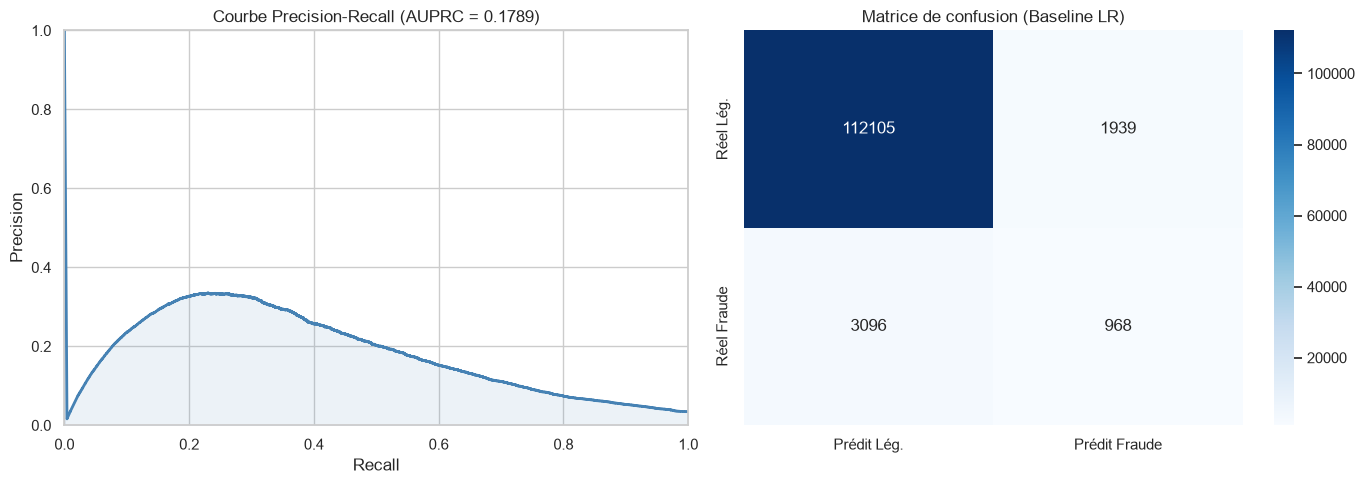

In [10]:
precision, recall, thresholds = precision_recall_curve(y_va, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe Precision-Recall
axes[0].plot(recall, precision, color='steelblue', lw=2)
axes[0].fill_between(recall, precision, alpha=0.1, color='steelblue')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Courbe Precision-Recall (AUPRC = {auprc:.4f})')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Matrice de confusion
cm = confusion_matrix(y_va, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Prédit Lég.', 'Prédit Fraude'],
            yticklabels=['Réel Lég.', 'Réel Fraude'])
axes[1].set_title('Matrice de confusion (Baseline LR)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_trap.png', dpi=150)
plt.show()

## 5. Feature Engineering

### 5.1 Proxy client

On crée un identifiant proxy client en combinant les colonnes carte et adresse disponibles.
Cette clé composite permet de calculer des features de vélocité par client.

In [11]:
proxy_cols = [c for c in ['card1','card2','card3','card4','card5','card6','addr1','addr2'] if c in df.columns]
df['customer_proxy'] = df[proxy_cols].astype(str).fillna('NA').agg('_'.join, axis=1)

print(f'Nombre de clients proxy uniques : {df["customer_proxy"].nunique():,}')
df[['TransactionDT', 'customer_proxy', 'TransactionAmt', TARGET]].head()

Nombre de clients proxy uniques : 43,071


,TransactionDT,customer_proxy,TransactionAmt,isFraud
0,86400,13926_nan_150.0_discover_142.0_credit_315.0_87.0,68.5000,0
1,86401,2755_404.0_150.0_mastercard_102.0_credit_325.0...,29.0000,0
2,86469,4663_490.0_150.0_visa_166.0_debit_330.0_87.0,59.0000,0
3,86499,18132_567.0_150.0_mastercard_117.0_debit_476.0...,50.0000,0
4,86506,4497_514.0_150.0_mastercard_102.0_credit_420.0...,50.0000,0


### 5.2 Features de vélocité

In [12]:
df['tx_time_sec'] = df['TransactionDT'].astype(float)

def rolling_count_and_sum(group, window_seconds):
    times = group['tx_time_sec'].values
    amts  = group['TransactionAmt'].values
    counts = np.zeros(len(times), dtype=int)
    sums   = np.zeros(len(times), dtype=float)
    for i in range(1, len(times)):
        mask = (times[:i] >= times[i] - window_seconds)
        counts[i] = mask.sum()
        sums[i]   = amts[:i][mask].sum()
    return counts, sums

WINDOWS = {'1h': 3600, '24h': 86400, '7d': 604800}

for label, seconds in WINDOWS.items():
    df[f'tx_count_{label}'] = 0
    df[f'tx_amt_sum_{label}'] = 0.0

print('Calcul des features de vélocité par client (peut prendre quelques minutes)...')
t0 = time.time()
for cid, grp in df.groupby('customer_proxy', sort=False):
    for label, seconds in WINDOWS.items():
        counts, sums = rolling_count_and_sum(grp, seconds)
        df.loc[grp.index, f'tx_count_{label}']   = counts
        df.loc[grp.index, f'tx_amt_sum_{label}'] = sums
print(f'Done en {time.time()-t0:.1f}s')

velocity_cols = [f'tx_count_{l}' for l in WINDOWS] + [f'tx_amt_sum_{l}' for l in WINDOWS]
df[velocity_cols].describe()

Calcul des features de vélocité par client (peut prendre quelques minutes)...
Done en 186.8s


,tx_count_1h,tx_count_24h,tx_count_7d,tx_amt_sum_1h,tx_amt_sum_24h,tx_amt_sum_7d
count,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000
mean,0.6435,5.8908,33.1877,74.8995,592.1263,3209.0510
std,4.6874,24.0024,80.1683,552.5339,2545.5243,6898.2217
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,1.0000,0.0000,0.0000,59.0000
50%,0.0000,1.0000,5.0000,0.0000,67.9500,584.0260
75%,0.0000,4.0000,26.0000,0.0000,458.8000,2984.0400
max,191.0000,880.0000,975.0000,68141.9531,94901.0000,103440.0000


### 5.3 Features comportementales

In [13]:
# Ratio montant courant / montant moyen sur 7 jours
df['amount_ratio_7d'] = df['TransactionAmt'] / (df['tx_amt_sum_7d'] / df['tx_count_7d'].clip(lower=1))
df['amount_ratio_7d'] = df['amount_ratio_7d'].replace([np.inf, -np.inf], 1.0).fillna(1.0)

# Détection nouveau marchand (proxy : card1 + ProductCD pas vu dans les 7 derniers jours)
df['merchant_proxy'] = df['card1'].astype(str) + '_' + df['ProductCD'].astype(str)

print('Features comportementales créées : amount_ratio_7d, merchant_proxy')
df[['amount_ratio_7d', 'merchant_proxy']].describe()

Features comportementales créées : amount_ratio_7d, merchant_proxy


,amount_ratio_7d
count,590540.0000
mean,1.2022
std,2.0199
min,0.0032
25%,0.5076
50%,1.0000
75%,1.1062
max,172.4439


## 6. Pipeline sklearn + TimeSeriesSplit

In [14]:
exclude = {'TransactionID', TARGET, 'customer_proxy', 'tx_time_sec', 'merchant_proxy'}
high_missing = df.columns[df.isna().mean() > 0.95].tolist()
print(f'Colonnes avec >95% NaN supprimées : {len(high_missing)}')

all_features = [c for c in df.columns if c not in exclude and c not in high_missing]

X = df[all_features]
y = df[TARGET]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Features numériques  : {len(num_features)}')
print(f'Features catégorielles : {len(cat_features)}')
print(f'Total features       : {len(all_features)}')

Colonnes avec >95% NaN supprimées : 9
Features numériques  : 404
Features catégorielles : 29
Total features       : 433


In [15]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=True))  # sparse=True : évite ~1.2 Go d'allocation dense
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
], remainder='drop')

phase1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

print('Pipeline phase 1 défini.')
print(phase1_pipeline)

Pipeline phase 1 défini.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['TransactionDT',
                                                   'TransactionAmt', 'card1',
                                                   'card2', 'card3', 'card5',
                                                   'addr1', 'addr2', 'dist1',
                                                   'dist2', 'C1', 'C2', 'C3',
                                                   'C4', 'C5', 'C6', 'C7', 'C8',
                                                   'C9', 'C10', 'C11', 'C12',
 

In [16]:
tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

print('Cross-validation temporelle en cours (5 folds)...')

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X), start=1):
    X_tr_f = X.iloc[tr_idx]
    X_va_f = X.iloc[va_idx]
    y_tr_f = y.iloc[tr_idx]
    y_va_f = y.iloc[va_idx]

    t0 = time.time()
    phase1_pipeline.fit(X_tr_f, y_tr_f)
    fit_time = time.time() - t0

    y_pred_f  = phase1_pipeline.predict(X_va_f)
    y_proba_f = phase1_pipeline.predict_proba(X_va_f)[:, 1]

    cv_results.append({
        'fold':         fold,
        'train_size':   len(tr_idx),
        'valid_size':   len(va_idx),
        'accuracy':     accuracy_score(y_va_f, y_pred_f),
        'recall_fraud': recall_score(y_va_f, y_pred_f),
        'AUPRC':        average_precision_score(y_va_f, y_proba_f),
        'fit_time_sec': fit_time
    })
    print(f"  Fold {fold} | AUPRC={cv_results[-1]['AUPRC']:.4f} | Recall={cv_results[-1]['recall_fraud']:.4f} | Acc={cv_results[-1]['accuracy']:.4f}")

cv_df = pd.DataFrame(cv_results)
print('\n=== Résultats CV ===')
print(cv_df.to_string(index=False))

Cross-validation temporelle en cours (5 folds)...
  Fold 1 | AUPRC=0.4060 | Recall=0.2319 | Acc=0.9723
  Fold 2 | AUPRC=0.4212 | Recall=0.2942 | Acc=0.9657
  Fold 3 | AUPRC=0.4046 | Recall=0.2564 | Acc=0.9687
  Fold 4 | AUPRC=0.4438 | Recall=0.3011 | Acc=0.9693
  Fold 5 | AUPRC=0.1900 | Recall=0.2552 | Acc=0.9577

=== Résultats CV ===
 fold  train_size  valid_size  accuracy  recall_fraud  AUPRC  fit_time_sec
    1       98425       98423    0.9723        0.2319 0.4060       20.8218
    2      196848       98423    0.9657        0.2942 0.4212       56.9577
    3      295271       98423    0.9687        0.2564 0.4046       92.7271
    4      393694       98423    0.9693        0.3011 0.4438      115.8424
    5      492117       98423    0.9577        0.2552 0.1900      159.8582


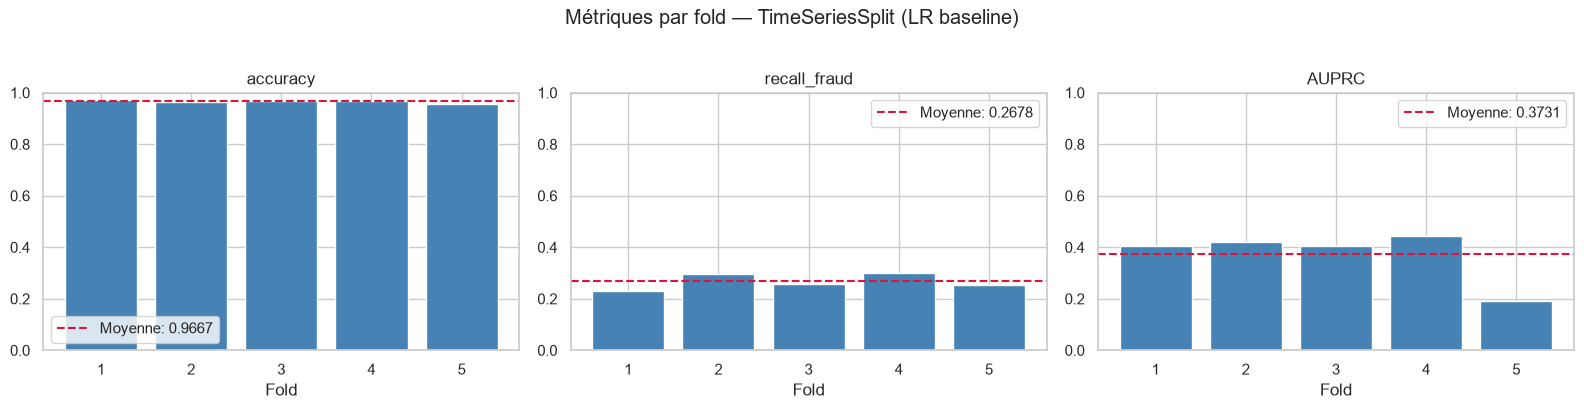

=== Moyennes CV ===
accuracy       0.9667
recall_fraud   0.2678
AUPRC          0.3731


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ['accuracy', 'recall_fraud', 'AUPRC']):
    ax.bar(cv_df['fold'], cv_df[metric], color='steelblue')
    ax.axhline(cv_df[metric].mean(), color='crimson', linestyle='--', label=f'Moyenne: {cv_df[metric].mean():.4f}')
    ax.set_title(metric)
    ax.set_xlabel('Fold')
    ax.legend()
    ax.set_ylim(0, 1)

plt.suptitle('Métriques par fold — TimeSeriesSplit (LR baseline)', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_metrics_baseline.png', dpi=150)
plt.show()

print('=== Moyennes CV ===')
print(cv_df[['accuracy','recall_fraud','AUPRC']].mean().to_string())

## 7. Conclusion Phase 1

**Ce que ce notebook a démontré** :
- L'accuracy est une métrique trompeuse sur données déséquilibrées (96.5% accuracy, mais recall très faible)
- Les features de vélocité (tx_count_1h/24h/7d) capturent le comportement frauduleux
- `TimeSeriesSplit` est indispensable pour éviter le data leakage temporel
- Le pipeline sklearn avec `sparse_output=True` permet de traiter 590k transactions sans MemoryError

**Prochaine étape** : Phase 2 — installation MLflow et entraînement des modèles XGBoost sur IEEE-CIS avec tracking complet.